## 📚 Índice do Notebook

1. [🌊🚨 Obtenção de Dados Extremos](#obtencao-de-dados-extremos)
    - [🧩 Tipos de Dados Utilizados](#-tipos-de-dados-utilizados)
    - [🔍 Resultado](#-resultado)
    - [🗓️ Dados Diários](#-dados-diários)
    - [⏰ Dados Subdiários (1h a 24h)](#-dados-subdiários-1h-a-24h)
    - [⏰ Dados Subdiários (5min a 30min)](#-dados-subdiários-5min-a-30min)
2. [📈 Geração da Curva IDF Histórica](#-geração-da-curva-idf)


# 📈 Automatic IDF Graphs – Geração de Curvas IDF Históricas

Este notebook demonstra o processo de construção de curvas Intensidade-Duração-Frequência (IDF) a partir de dados históricos de precipitação.

🎯 O passo fundamental é a extração das séries de máximos anuais para diversas durações, que servirão de base para o ajuste estatístico e a geração da curva final.

<br>

## 🛠️ O que este notebook faz?

Neste notebook, vamos:

- 🔍 Importar e explorar dados de exemplo  
- 📚 Demonstrar as principais funções da biblioteca  
- 📊 Gerar gráficos e curvas IDF com base em dados reais  
- ✅ Validar resultados com visualizações claras  

#### Continuaremos seguindo o passo a passo claro. Para isso, teremos que resgatar algumas funções do notebook anterior:

In [6]:
from idf_analysis.data.processing import read_csv, fill_missing_data

# Captando os dados
cemaden_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')
inmet_df = read_csv(path='../results/inmet_sao_paulo_mirante/inmet_sao_paulo_mirante_hourly.csv')
inmet_daily_df = read_csv(path='../results/inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante_daily.csv')
climbra_hist_df = read_csv(path='../results/CABra467/historical/1980-2013_daily.csv')

# Preenchendo falhas
cemaden_df = fill_missing_data(df_main=cemaden_df,
                               df_secondary=inmet_df,
                               frequency='hourly',)

---
## 🌊🚨 Obtenção de Dados Extremos

### 🎯 Por que extrair dados extremos?

Para gerar curvas **IDF (Intensidade-Duração-Frequência)** precisas, é necessário identificar os **maiores eventos de precipitação** registrados ao longo do tempo — esses são os chamados **dados extremos**. Eles representam as chuvas mais intensas em diferentes escalas temporais.

### 🧩 Tipos de Dados Utilizados

1. **📅 Dados Diários**  
   - Considera o **maior valor de precipitação por dia** ao longo de cada ano.  
   - Base para desagregações ou análises mais simples.

2. **🕒 Dados Subdiários em Horas**  
   - Dados medidos hora a hora.  
   - Calcula-se o **acumulado máximo** em janelas móveis de:  
     `1h, 3h, 6h, 8h, 10h, 12h, 24h`

3. **🕔 Dados Subdiários em Minutos**  
   - Dados com resolução fina (ex.: a cada 5 ou 10 minutos).  
   - Permite estimar extremos em intervalos curtos:  
     `5min, 10min, 15min, 20min, 25min e 30min`  
   - Ideal para áreas urbanas e estudos de microdrenagem.

### 🔍 Resultado

- Tabelas com **valores máximos por ano** para cada duração.
- Base para ajuste de distribuições estatísticas.

### 🗓️ Dados Diários 

In [7]:
from idf_analysis.analysis.historical.validation import max_annual_precipitation

max_annual_cemaden = max_annual_precipitation(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')
max_annual_inmet = max_annual_precipitation(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante/', frequency='hourly')

print("\n📊 CEMADEN - Máximos anuais:")
display(max_annual_cemaden)

print("\n📊 INMET - Máximos anuais:")
display(max_annual_inmet)


📊 CEMADEN - Máximos anuais:


,Year,Precipitation
0,2014,67.3700
2,2016,57.6051
3,2017,84.6900
4,2018,70.1800
5,2019,35.9680
6,2020,49.5590
7,2021,39.8215
8,2022,58.2400
9,2023,55.2293
10,2024,63.7800



📊 INMET - Máximos anuais:


,Year,Precipitation
0,2014,73.6
1,2015,87.2
2,2016,82.8
3,2017,120.8
4,2018,96.4
5,2019,98.6
6,2020,143.0
7,2021,55.6
8,2022,64.2
9,2023,64.2


### ⏰ Dados Subdiários (1h, 3h, 6h, 8h, 10h, 12h, 24h)

In [8]:
from idf_analysis.analysis.historical.subdaily import get_max_subdaily_table

incomplete_subdaily_cemaden = get_max_subdaily_table(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao')

print("\n📊 CEMADEN - Máximos subdiários:")
display(incomplete_subdaily_cemaden)

incomplete_subdaily_inmet = get_max_subdaily_table(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante')

print("\n📊 INMET - Máximos subdiários:")
display(incomplete_subdaily_inmet)




[OK] Resultados salvos em: ../results/cemaden_ac_santana_sao/max_subdaily_cemaden_ac_santana_sao.csv

📊 CEMADEN - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.00,55.46,63.04,64.22,67.36,68.36,119.54
1,2015,43.99,89.54,94.08,94.28,94.48,94.48,104.33
2,2016,25.82,40.08,51.44,58.46,60.39,60.54,64.20
3,2017,26.84,55.56,67.17,67.97,68.35,70.52,87.44
4,2018,12.20,17.70,26.50,34.36,42.61,49.68,74.89
5,2019,25.98,31.88,34.25,36.14,36.14,36.34,46.46
6,2020,12.40,17.54,31.37,32.01,32.42,40.98,50.69
7,2021,11.47,21.08,30.07,36.94,41.95,43.81,57.55
8,2022,37.38,44.45,44.65,44.65,44.65,44.65,62.58
9,2023,30.74,41.03,43.01,43.81,43.81,44.20,56.44



[OK] Resultados salvos em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante.csv

📊 INMET - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.2,52.0,70.6,71.0,71.0,71.0,118.8
1,2015,77.8,87.2,87.2,87.2,87.2,87.2,100.0
2,2016,39.6,61.2,68.6,94.8,99.8,99.8,99.8
3,2017,64.6,97.0,101.8,113.4,113.4,113.4,121.8
4,2018,29.2,57.6,71.4,71.8,74.4,75.0,99.4
5,2019,67.6,88.0,92.6,94.0,94.2,94.2,126.4
6,2020,44.4,61.8,96.6,115.6,127.0,133.0,150.8
7,2021,31.0,48.4,48.4,48.6,49.4,49.4,63.6
8,2022,44.4,51.4,52.8,52.8,52.8,52.8,74.8
9,2023,56.6,61.8,73.0,73.6,75.4,76.0,81.0


### ⏰ Dados Subdiários (5min, 10min, 15min, 20min, 25min e 30min)

In [9]:
from idf_analysis.analysis.historical.intervals import DisaggregationScenario, get_subdaily_from_disaggregation_factors

var_value = 0.1 # Valor de exemplo para variação de precipitação

subdaily_cemaden = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_cemaden,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='cemaden_ac_santana_sao', 
    output_dir='../results/cemaden_ac_santana_sao'
)

print("\n📊 CEMADEN - Subdiários obtidos:")
display(subdaily_cemaden)
        
subdaily_inmet = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_inmet,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='inmet_sao_paulo_mirante',
    output_dir='../results/inmet_sao_paulo_mirante'
)

print("\n📊 INMET - Subdiários obtidos:")
display(subdaily_inmet)


[OK] Resultado salvo em: ../results/cemaden_ac_santana_sao/max_subdaily_cemaden_ac_santana_sao_ger.csv

📊 CEMADEN - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,57.24,55.46,98.12,106.29,111.75,115.83,136.28,14.40,22.87,29.65,34.31,38.54,42.35
1,2015,49.95,89.54,85.63,92.77,97.53,101.10,118.94,12.57,19.96,25.88,29.94,33.64,36.97
2,2016,30.74,40.08,52.70,57.09,60.01,62.21,73.19,7.73,12.28,15.92,18.42,20.70,22.75
3,2017,41.87,55.56,71.77,77.75,81.74,84.73,99.68,10.53,16.73,21.69,25.09,28.19,30.98
4,2018,35.86,17.70,61.47,66.59,70.01,72.57,85.37,9.02,14.33,18.57,21.49,24.15,26.53
5,2019,22.25,31.88,38.13,41.31,43.43,45.02,52.96,5.60,8.89,11.52,13.33,14.98,16.46
6,2020,24.27,17.54,41.61,45.07,47.39,49.12,57.79,6.11,9.70,12.57,14.55,16.34,17.96
7,2021,27.55,21.08,47.24,51.17,53.80,55.77,65.61,6.93,11.01,14.27,16.52,18.56,20.39
8,2022,29.96,44.45,51.37,55.65,58.50,60.64,71.34,7.54,11.97,15.52,17.96,20.18,22.17
9,2023,27.02,41.03,46.33,50.19,52.76,54.69,64.34,6.80,10.80,14.00,16.20,18.20,20.00


[OK] Resultado salvo em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante_ger.csv

📊 INMET - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,56.88,52.0,97.51,105.64,111.05,115.12,135.43,14.31,22.73,29.46,34.09,38.30,42.09
1,2015,47.88,87.2,82.08,88.92,93.48,96.90,114.00,12.05,19.13,24.80,28.70,32.24,35.43
2,2016,47.78,61.2,81.92,88.74,93.29,96.71,113.77,12.02,19.09,24.75,28.64,32.18,35.36
3,2017,58.32,97.0,99.97,108.30,113.86,118.02,138.85,14.67,23.30,30.21,34.96,39.27,43.16
4,2018,47.59,57.6,81.59,88.39,92.92,96.32,113.32,11.97,19.02,24.65,28.53,32.05,35.22
5,2019,60.52,88.0,103.75,112.39,118.16,122.48,144.10,15.23,24.18,31.35,36.28,40.75,44.79
6,2020,72.20,61.8,123.78,134.09,140.97,146.13,171.91,18.17,28.85,37.40,43.28,48.62,53.43
7,2021,30.45,48.4,52.20,56.55,59.45,61.63,72.50,7.66,12.17,15.77,18.25,20.51,22.53
8,2022,35.81,51.4,61.40,66.51,69.92,72.48,85.27,9.01,14.31,18.55,21.47,24.12,26.50
9,2023,38.78,61.8,66.48,72.03,75.72,78.49,92.34,9.76,15.50,20.09,23.25,26.12,28.70


---
## 📈 Geração da Curva IDF Histórica

Agora vamos gerar as **curvas IDF (Intensidade-Duração-Frequência)** a partir dos dados históricos processados.

### 🎯 O que são Curvas IDF?

As curvas IDF estabelecem a relação entre:
- **Intensidade** (mm/h): Taxa de precipitação
- **Duração** (min/h): Tempo do evento chuvoso  
- **Frequência** (anos): Período de retorno

### 🔧 Processo

1. **Ajuste estatístico** dos dados extremos
2. **Calibração dos parâmetros** da equação IDF
3. **Geração das tabelas** e gráficos

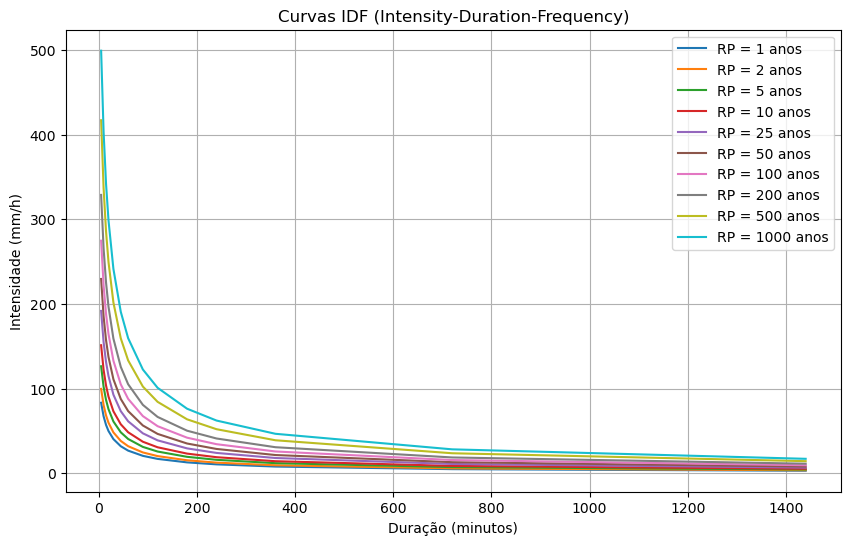

In [10]:
from idf_analysis.analysis.historical.idf import get_final_idf

get_final_idf(
    name_file='cemaden_ac_santana_sao',
    directory='../results/cemaden_ac_santana_sao',
    disag_factor='ger',
    save_file=True,
    plot=True,
);